# Challenge 3: TelecomX Churn Prediction
**Programa Alura + Oracle Next Education (ONE)**

Olá! Este projeto foi desenvolvido por mim como aluna do Oracle Next Education (ONE), um programa de formação focado em tecnologia promovido pela Oracle em parceria com a Alura.

Este projeto é o 3º Challenge, onde o objetivo é desenvolver modelos de Machine Learning para prever a evasão de clientes (Churn) da empresa de telecomunicações TelecomX. O pipeline engloba desde a extração dos dados brutos, tratamento de nulos, codificação de variáveis categóricas, balanceamento de classes com SMOTE e avaliação comparativa de múltiplos algoritmos de classificação utilizando Pipelines do Scikit-Learn.

In [1]:
# --- ETAPA 1: IMPORTAÇÃO DE BIBLIOTECAS E EXTRAÇÃO ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Pré-processamento e Divisão de Dados
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Algoritmos de Machine Learning 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Métricas de Avaliação
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Carregar dados brutos direto da URL
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json'
df_raw = pd.read_json(url)

# Mostrar primeiras linhas
df_raw.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


## 2. Limpeza e Padronização dos Dados
Nesta etapa, padronizamos os nomes das colunas para *snake_case*, removemos registros duplicados, tratamos estruturas aninhadas do JSON e corrigimos tipos de dados incorretos.

In [2]:
# --- ETAPA 2: PADRONIZAÇÃO E LIMPEZA ---
df = df_raw.copy()

# 1. Padronizar nomes das colunas para minúsculo e sem espaços
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# 2. Desaninhar dicionários (JSON) usando o método .map() atualizado
if any(df.map(lambda x: isinstance(x, dict)).any()):
    df = pd.json_normalize(df.to_dict(orient="records"))

# 3. Remover registros duplicados
df = df.drop_duplicates()

# 4. Corrigir valores ausentes para o padrão do Pandas
df = df.fillna(pd.NA)

# 5. Forçar conversão da coluna de cobrança total para numérico
if 'account.charges.total' in df.columns:
    df['account.charges.total'] = pd.to_numeric(df['account.charges.total'], errors='coerce')

# 6. Remover IDs e colunas irrelevantes para a modelagem matemática
cols_to_drop = ["customer_id", "account_id", "phone_number", "customerid"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors="ignore")

df.head()

,churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


## 3. Divisão dos Dados e Engenharia de Features
Para evitar o **Data Leakage (Vazamento de Dados)**, primeiro separamos a variável alvo (`churn`) e dividimos o dataset em conjuntos de **Treino (70%)** e **Teste (30%)**. Mapeamos o target para valores binários (0 e 1).

In [3]:
# --- ETAPA 3: DIVISÃO ENTRE TREINO E TESTE (DIAGNÓSTICO AUTOMÁTICO) ---
import pandas as pd
from sklearn.model_selection import train_test_split

if "churn" in df.columns:
    # 1. ESPIONAR OS DADOS: Imprime o que realmente existe dentro da coluna churn
    print("--- Valores reais encontrados na coluna 'churn' original ---")
    print(df["churn"].value_counts(dropna=False))
    print("-" * 60)
    
    # 2. SE FOR BOOLEANO (True/False): Trata automaticamente se o pandas tiver lido como booleano
    if df["churn"].dtype == 'bool':
        df["churn"] = df["churn"].astype(int)
    else:
        # Se for texto, aplica o mapa estendido
        mapeamento_churn = {
            'Yes': 1, 'No': 0,
            'yes': 1, 'no': 0,
            '1': 1, '0': 0,
            1: 1, 0: 0
        }
        df["churn"] = df["churn"].map(mapeamento_churn)
    
    # 3. Remove linhas que restaram nulas
    df = df.dropna(subset=["churn"])
    
    # Verificação crítica de tamanho
    if df.shape[0] == 0:
        raise ValueError("O DataFrame ficou vazio após o mapeamento. Confira o print do 'Value counts' acima para ver o lixo que veio na coluna.")
        
    y = df["churn"].astype(int)
    X = df.drop(columns=["churn"])
else:
    raise ValueError("Coluna 'churn' não encontrada no DataFrame.")

# One-Hot Encoding aplicado nas variáveis explicativas
X_encoded = pd.get_dummies(X, drop_first=True)

# Tratar valores ausentes calculando a mediana nas features
X_encoded = X_encoded.fillna(X_encoded.median(numeric_only=True))
X_encoded = X_encoded.fillna(0)

# Divisão estratificada (Treino 70% / Teste 30%)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y
)

print(f"\n✓ Sucesso! O dataset foi dividido corretamente.")
print(f"Tamanho do Treino: {X_train.shape[0]} amostras")
print(f"Tamanho do Teste: {X_test.shape[0]} amostras")

--- Valores reais encontrados na coluna 'churn' original ---
churn
No     5174
Yes    1869
        224
Name: count, dtype: int64
------------------------------------------------------------

✓ Sucesso! O dataset foi dividido corretamente.
Tamanho do Treino: 4930 amostras
Tamanho do Teste: 2113 amostras


## 4. Balanceamento de Classes (SMOTE)
Aplicamos o algoritmo SMOTE **exclusivamente no conjunto de treino** para equalizar a proporção de clientes com e sem Churn, impedindo que os modelos fiquem viesados a favor da classe majoritária.

In [4]:
# --- ETAPA 4: BALANCEAMENTO APENAS NO TREINO ---
print("Distribuição original no treino:", Counter(y_train))

# Aplicar o SMOTE exclusivamente nos dados de treino para blindar o teste
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Distribuição após SMOTE no treino:", Counter(y_train_res))

Distribuição original no treino: Counter({0: 3622, 1: 1308})
Distribuição após SMOTE no treino: Counter({0: 3622, 1: 3622})


## 5. Treinamento de Modelos via Pipelines
Criamos pipelines estruturados contendo o escalonamento dos dados numéricos (`StandardScaler`) e os algoritmos de classificação. Os modelos serão alimentados com os dados balanceados pelo SMOTE.

In [5]:
# --- ETAPA 5: CONFIGURAÇÃO E TREINO DOS MODELOS ---
modelos = {
    "Logistic Regression": Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(random_state=42))]),
    "Random Forest": Pipeline([('scaler', StandardScaler()), ('rf', RandomForestClassifier(random_state=42))]),
    "KNN": Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])
}

# Treinar os modelos utilizando os dados de treino balanceados pelo SMOTE
for nome, pipeline in modelos.items():
    pipeline.fit(X_train_res, y_train_res)
    print(f"Modelo [{nome}] treinado com sucesso!")

Modelo [Logistic Regression] treinado com sucesso!
Modelo [Random Forest] treinado com sucesso!
Modelo [KNN] treinado com sucesso!


## 6. Avaliação de Métricas e Performance
Avaliamos os modelos utilizando o conjunto de teste (com dados reais e não modificados pelo SMOTE). Analisamos o F1-Score, Precisão, Recall e geramos as matrizes de confusão.

In [6]:
# --- ETAPA 6: AVALIAÇÃO COMPARATIVA ---
resultados = []

for nome, pipeline in modelos.items():
    y_pred = pipeline.predict(X_test)
    
    # Métricas calculadas em cima do conjunto de teste real (não balanceado)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, zero_division=0, digits=4)
    
    resultados.append({
        'Modelo': nome, 
        'Acurácia': acc, 
        'Precisão': prec, 
        'Recall': rec, 
        'F1-Score': f1, 
        'cm': cm, 
        'report': report
    })

# Exibir tabela de performance resumida ordenada pelo melhor F1-Score
res_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ('cm','report')} for r in resultados])
res_df = res_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
display(res_df)

,Modelo,Acurácia,Precisão,Recall,F1-Score
0,Random Forest,0.784193,0.596685,0.577540,0.586957
1,Logistic Regression,0.733554,0.498734,0.702317,0.583272
2,KNN,0.731188,0.454545,0.062389,0.109718


### Visualização das Matrizes de Confusão
Plotagem gráfica das previsões corretas (verdadeiros positivos/negativos) versus erros cometidos por cada algoritmo.

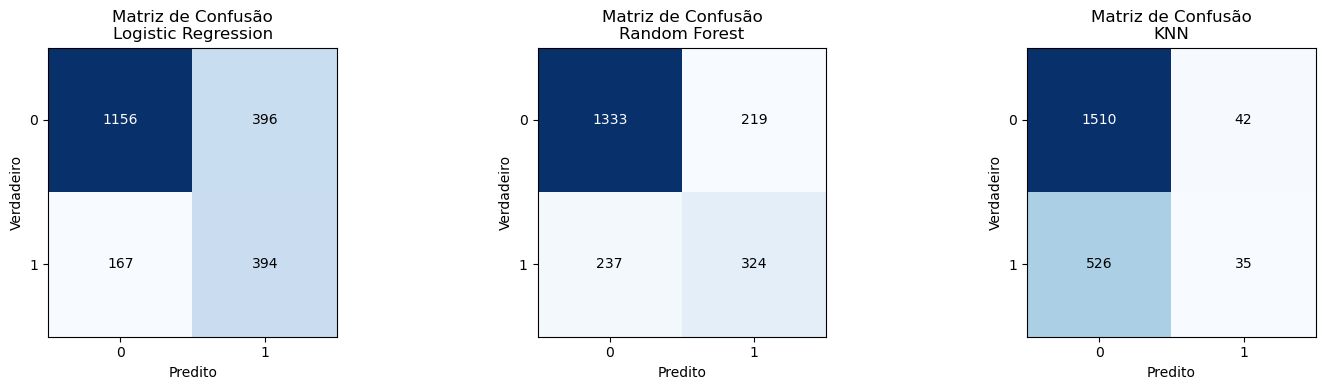

In [7]:
# --- ETAPA 7: PLOT DAS MATRIZES DE CONFUSÃO ---
n = len(resultados)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
if n == 1: axes = [axes]

for ax, r in zip(axes, resultados):
    cm = r['cm']
    ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(f"Matriz de Confusão\n{r['Modelo']}")
    ax.set_xlabel('Predito')
    ax.set_ylabel('Verdadeiro')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, int(val), ha='center', va='center', 
                color='white' if cm.max() > 10 and cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

## 7. Análise de Importância das Variáveis (Feature Importance)
Verificamos quais fatores do histórico do cliente possuem o maior peso na decisão final dos algoritmos (Regressão Logística e Random Forest).

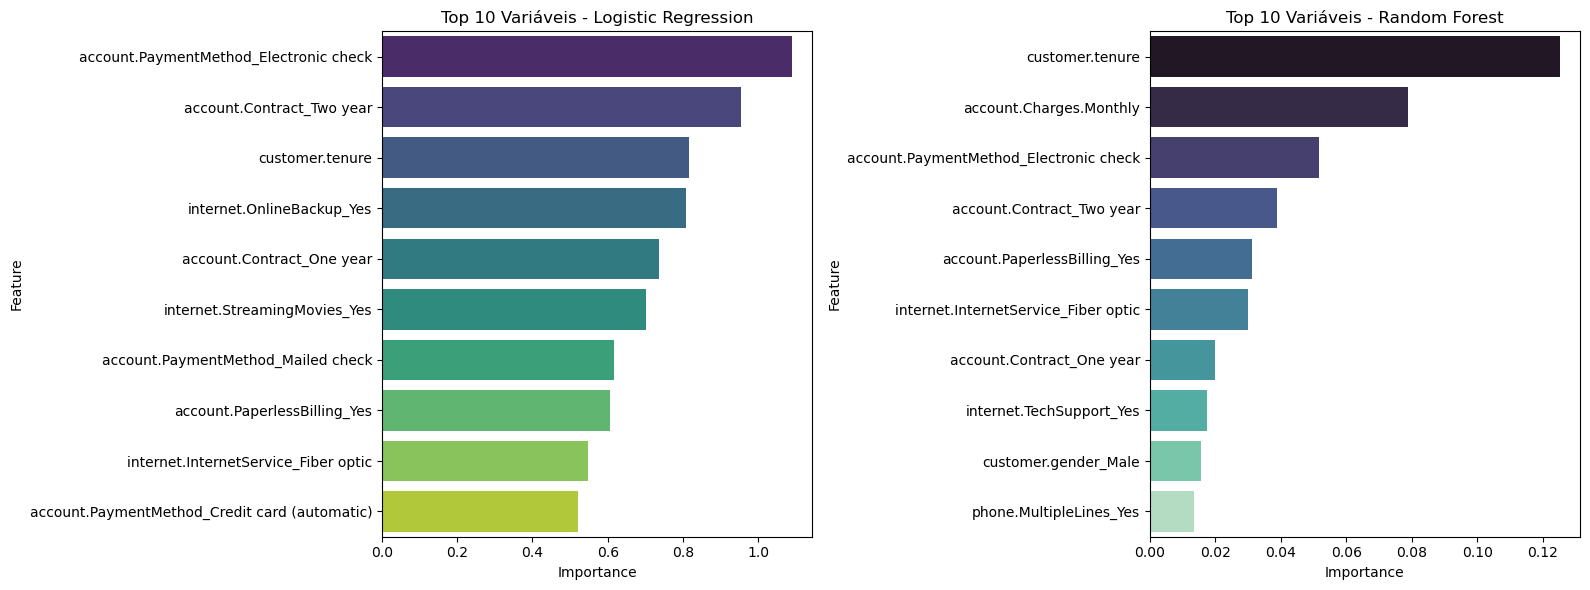

In [8]:
# --- ETAPA 8: FEATURE IMPORTANCE ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

feature_names = X_train.columns

# 1. Coeficientes da Regressão Logística
lr_model = modelos["Logistic Regression"].named_steps['lr']
feature_importance_lr = pd.DataFrame({
    'Feature': feature_names,
    'Importance': abs(lr_model.coef_[0])
}).sort_values(by='Importance', ascending=False)

# 2. Importância por Gini do Random Forest
rf_model = modelos["Random Forest"].named_steps['rf']
feature_importance_rf = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot dos Top 10 fatores que mais influenciam o Churn
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico da Regressão Logística corrigido
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_lr.head(10), 
    ax=ax1, 
    hue='Feature',      
    palette='viridis', 
    legend=False        
)
ax1.set_title('Top 10 Variáveis - Logistic Regression')

# Gráfico do Random Forest corrigido
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_rf.head(10), 
    ax=ax2, 
    hue='Feature',      
    palette='mako', 
    legend=False        
)
ax2.set_title('Top 10 Variáveis - Random Forest')

plt.tight_layout()
plt.show()

## 9. Análise da Curva ROC e AUC (Área Sob a Curva)
Para consolidar a escolha do melhor classificador, analisamos a **Curva ROC** (*Receiver Operating Characteristic*) e a métrica **AUC** (*Area Under the Curve*). 

A Curva ROC plota a **Taxa de Verdadeiros Positivos (Sensibilidade/Recall)** contra a **Taxa de Falsos Positivos (1 - Especificidade)** para diferentes limiares de decisão. 
* O valor de **AUC** varia de 0.5 (desempenho equivalente a um palpite aleatório) a 1.0 (classificador perfeito).
* Esta análise é o padrão-ouro na Ciência de Dados para medir a capacidade do modelo em distinguir entre as classes (Clientes Estáveis vs. Clientes em Risco de Churn) sem ser afetado pelo desbalanceamento.

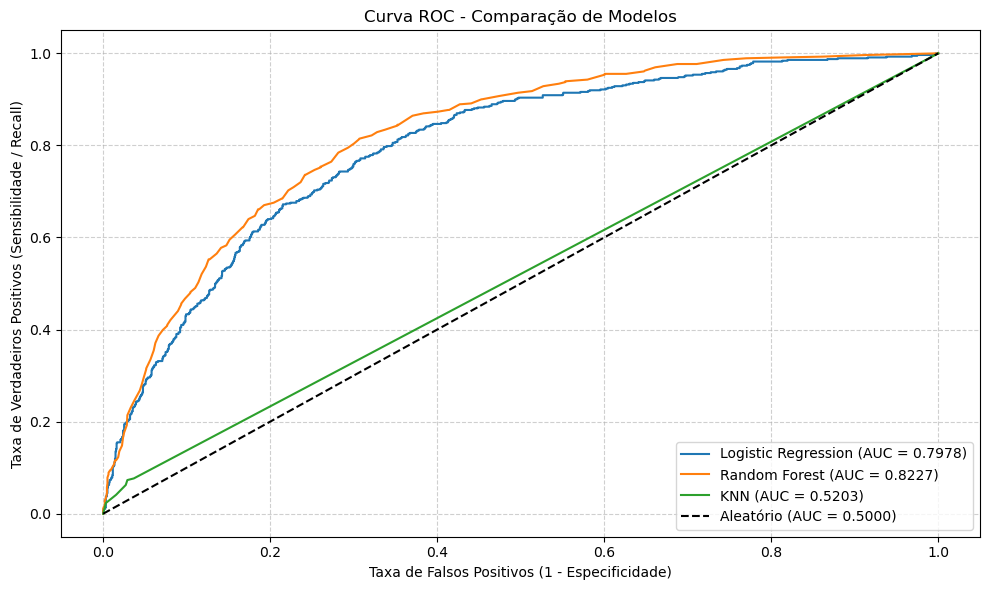

In [ ]:
# --- ETAPA 9: CURVA ROC COMPARATIVA ---
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for nome, pipeline in modelos.items():
    # Obter as probabilidades para a classe positiva
    if hasattr(pipeline, "predict_proba"):
        y_probs = pipeline.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_probs)
        auc_score = roc_auc_score(y_test, y_probs)
        plt.plot(fpr, tpr, label=f"{nome} (AUC = {auc_score:.4f})")

# Gráfico da linha de base (modelo aleatório)
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.5000)')

plt.title('Curva ROC - Comparação de Modelos')
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade / Recall)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()